# Thực nghiệm ENN trên Waveform+Noise

Mục tiêu là kiểm tra tác động của ENN lên KNN trên bộ dữ liệu Waveform+Noise.


# 1. Import thư viện

Phần này nạp các thư viện cần dùng cho xử lý dữ liệu, mô hình và trực quan hóa.


In [ ]:
# Import thư viện cần dùng
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from imblearn.under_sampling import EditedNearestNeighbours
from sklearn.datasets import make_moons
from pathlib import Path


# 2. Chuẩn bị dữ liệu

Dữ liệu được đọc từ file CSV và kiểm tra kích thước, số lớp, phân bố nhãn.


## 2.1. Minh họa Two Moons

Ví dụ 2D này chỉ dùng để minh họa vùng điểm bị ENN loại bỏ.


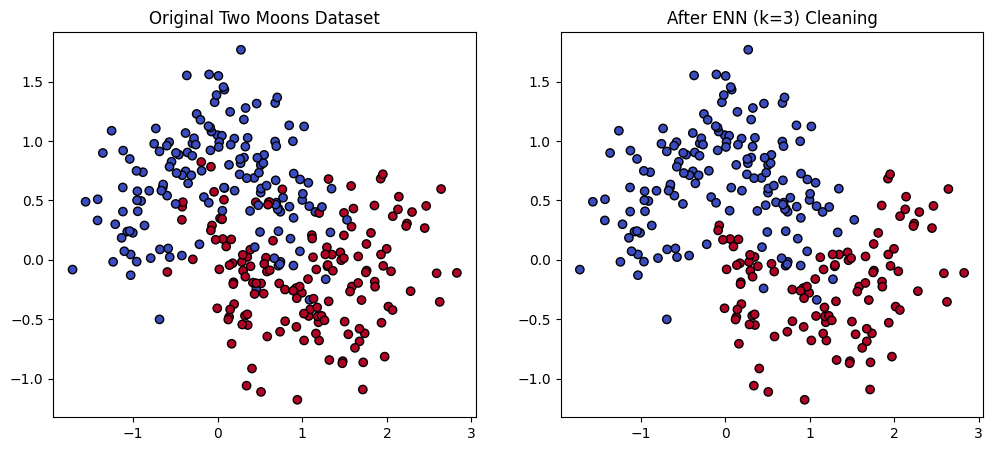

In [ ]:
# Demo nhỏ để nhìn cách ENN lọc điểm
X_moons, y_moons = make_moons(n_samples=300, noise=0.3, random_state=42)

enn_illustrator = EditedNearestNeighbours(n_neighbors=3)
X_moons_resampled, y_moons_resampled = enn_illustrator.fit_resample(X_moons, y_moons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='coolwarm', edgecolors='k')
ax1.set_title('Original Two Moons Dataset')
ax2.scatter(X_moons_resampled[:, 0], X_moons_resampled[:, 1], c=y_moons_resampled, cmap='coolwarm', edgecolors='k')
ax2.set_title('After ENN (k=3) Cleaning')
plt.show()


## 2.2. Dataset Waveform+Noise

Đây là dataset chính dùng để chạy baseline và các thí nghiệm ENN.


In [ ]:
# Đọc dataset chính
dataset_candidates = [
    Path("../datasets/waveform_noise.csv"),
    Path("datasets/waveform_noise.csv"),
]
dataset_path = next((path for path in dataset_candidates if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError("Cannot find datasets/waveform_noise.csv")

df = pd.read_csv(dataset_path)
X = df.drop(columns=["class"])
y = df["class"]

print("Dataset path:", dataset_path)
print("Dataset shape:", df.shape)
print("Feature shape X:", X.shape)
print("Phân phối class ban đầu:")
print(pd.Series(y).value_counts().sort_index())


Dataset path: ../datasets/waveform_noise.csv
Dataset shape: (5000, 41)
Feature shape X: (5000, 40)
Phân phối class ban đầu:
class
0    1692
1    1653
2    1655
Name: count, dtype: int64


## 2.3. Chia train/test

Train set dùng để lọc bằng ENN, còn test set được giữ nguyên để so sánh công bằng.


In [ ]:
# Chia train/test cố định
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('Kích thước tập train:', X_train.shape)
print('Kích thước tập test:', X_test.shape)


Kích thước tập train: (3500, 40)
Kích thước tập test: (1500, 40)


## 2.4. Chuẩn hóa dữ liệu

Các thuộc tính được chuẩn hóa vì KNN và ENN đều dựa trên khoảng cách giữa các điểm.


In [ ]:
# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 3. Hàm đánh giá

Hàm này gom các chỉ số đánh giá để các lần chạy có cùng format kết quả.


In [ ]:
# Hàm in metric và confusion matrix
def evaluate_model(y_true, y_pred, model_name='Model'):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")
    f1_macro = f1_score(y_true, y_pred, average="macro")

    print(f"========================================")
    print(f"{model_name}")
    print(f"========================================")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1_weighted:.4f}")
    print(f"Macro F1  : {f1_macro:.4f}")
    print("\n========== CONFUSION MATRIX ==========")
    print(confusion_matrix(y_true, y_pred))
    print("\n========== CLASSIFICATION REPORT ==========")
    print(classification_report(y_true, y_pred))

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': precision,
        'Recall': recall,
        'F1_Weighted': f1_weighted,
        'F1_Macro': f1_macro
    }

# 4. Thực nghiệm chính

Phần này chạy KNN ban đầu, sau đó chạy KNN trên dữ liệu đã được ENN lọc.


## 4.1. Baseline KNN

Baseline dùng toàn bộ train set ban đầu, chưa áp dụng bước lọc mẫu.


In [ ]:
# Baseline: KNN chưa dùng ENN
knn_original = KNeighborsClassifier(n_neighbors=5)
knn_original.fit(X_train_scaled, y_train)

y_pred_original = knn_original.predict(X_test_scaled)
res_original = evaluate_model(y_test, y_pred_original, 'KNN (No ENN)')
res_original['Train_size'] = len(y_train)
res_original['Removed'] = 0
res_original['Removed_rate_%'] = 0.0


KNN (No ENN)
Accuracy  : 0.7833
Precision : 0.7840
Recall    : 0.7833
F1-score  : 0.7835
Macro F1  : 0.7837

========== CONFUSION MATRIX ==========
[[396  55  57]
 [ 69 389  38]
 [ 62  44 390]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.75      0.78      0.77       508
           1       0.80      0.78      0.79       496
           2       0.80      0.79      0.80       496

    accuracy                           0.78      1500
   macro avg       0.78      0.78      0.78      1500
weighted avg       0.78      0.78      0.78      1500



## 4.2. ENN với kind set all

ENN được chạy với nhiều giá trị k để xem mức lọc dữ liệu ảnh hưởng đến kết quả ra sao.


In [ ]:
# Chạy ENN với k = 3, 5, 7
results = [res_original]
enn_values = [3, 5, 7]

for k in enn_values:
    enn = EditedNearestNeighbours(n_neighbors=k, sampling_strategy="all", kind_sel="all")
    X_train_enn, y_train_enn = enn.fit_resample(X_train_scaled, y_train)

    before_samples = len(y_train)
    after_samples = len(y_train_enn)
    print(f"\nENN EXPERIMENT - k = {k}")
    print("========== SAMPLE ANALYSIS ==========")
    print(f"Before ENN : {before_samples}")
    print(f"After ENN  : {after_samples}")
    print(f"Removed    : {before_samples - after_samples}")

    orig_counts = pd.Series(y_train).value_counts().sort_index()
    enn_counts = pd.Series(y_train_enn).value_counts().sort_index()
    print("========== REMOVED SAMPLES BY CLASS ==========")
    for class_label in sorted(orig_counts.index):
        removed = orig_counts[class_label] - enn_counts.get(class_label, 0)
        print(f"Removed Class {class_label}: {removed}")

    knn_enn = KNeighborsClassifier(n_neighbors=5)
    knn_enn.fit(X_train_enn, y_train_enn)
    y_pred_enn = knn_enn.predict(X_test_scaled)

    res_enn = evaluate_model(y_test, y_pred_enn, f'ENN k={k}')
    res_enn['Train_size'] = after_samples
    res_enn['Removed'] = before_samples - after_samples
    res_enn['Removed_rate_%'] = (before_samples - after_samples) / before_samples * 100
    results.append(res_enn)


ENN EXPERIMENT - k = 3
========== SAMPLE ANALYSIS ==========
Before ENN : 3500
After ENN  : 1377
Removed    : 2123
========== REMOVED SAMPLES BY CLASS ==========
Removed Class 0: 741
Removed Class 1: 688
Removed Class 2: 694
ENN k=3
Accuracy  : 0.8027
Precision : 0.8045
Recall    : 0.8027
F1-score  : 0.8020
Macro F1  : 0.8022

========== CONFUSION MATRIX ==========
[[397  34  77]
 [ 88 372  36]
 [ 26  35 435]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       508
           1       0.84      0.75      0.79       496
           2       0.79      0.88      0.83       496

    accuracy                           0.80      1500
   macro avg       0.80      0.80      0.80      1500
weighted avg       0.80      0.80      0.80      1500


ENN EXPERIMENT - k = 5
========== SAMPLE ANALYSIS ==========
Before ENN : 3500
After ENN  : 867
Removed    : 2633
========== REMOVED SAMPLES BY CLASS ========

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       508
           1       0.84      0.77      0.81       496
           2       0.80      0.88      0.83       496

    accuracy                           0.81      1500
   macro avg       0.81      0.81      0.81      1500
weighted avg       0.81      0.81      0.81      1500




ENN EXPERIMENT - k = 7
========== SAMPLE ANALYSIS ==========
Before ENN : 3500
After ENN  : 551
Removed    : 2949
========== REMOVED SAMPLES BY CLASS ==========
Removed Class 0: 999
Removed Class 1: 963
Removed Class 2: 987
ENN k=7
Accuracy  : 0.8120
Precision : 0.8135
Recall    : 0.8120
F1-score  : 0.8113
Macro F1  : 0.8115

========== CONFUSION MATRIX ==========
[[397  33  78]
 [ 78 382  36]
 [ 19  38 439]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       508
           1       0.84      0.77      0.81       496
           2       0.79      0.89      0.84       496

    accuracy                           0.81      1500
   macro avg       0.81      0.81      0.81      1500
weighted avg       0.81      0.81      0.81      1500



# 5. Tổng hợp kết quả

Các bảng và biểu đồ bên dưới dùng để so sánh baseline với các mô hình sau ENN.


,Model,Accuracy,Precision,Recall,F1_Weighted,F1_Macro,Train_size,Removed,Removed_rate_%
0,KNN (No ENN),0.783333,0.783964,0.783333,0.783511,0.783658,3500,0,0.000000
1,ENN k=3,0.802667,0.804524,0.802667,0.802000,0.802184,1377,2123,60.657143
2,ENN k=5,0.806667,0.807831,0.806667,0.806095,0.806317,867,2633,75.228571
3,ENN k=7,0.812000,0.813508,0.812000,0.811334,0.811487,551,2949,84.257143


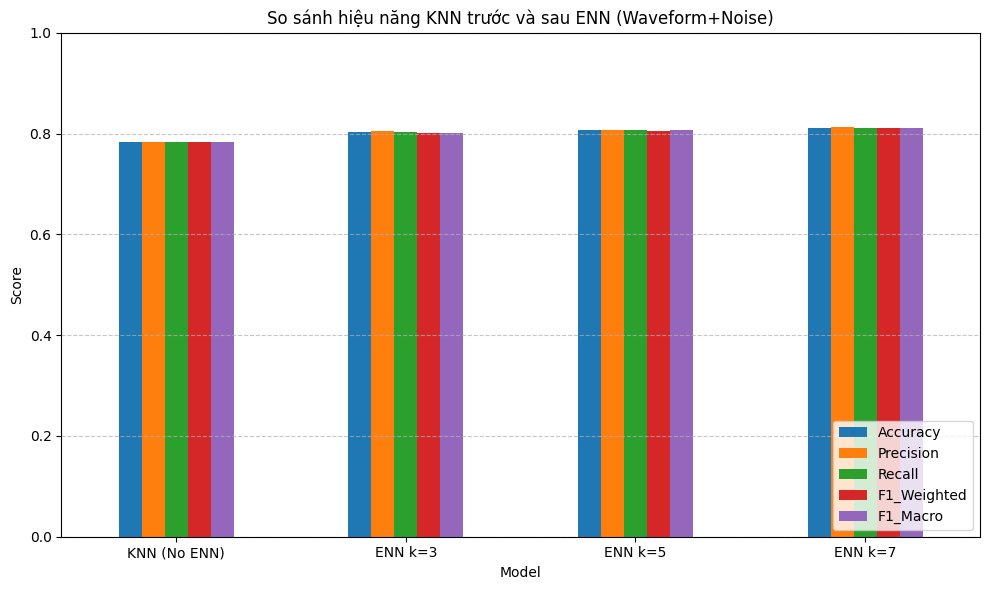

In [ ]:
# Tổng hợp kết quả chính
df_results = pd.DataFrame(results)
display(df_results)

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1_Weighted', 'F1_Macro']
df_results.set_index('Model')[metric_cols].plot(kind='bar', figsize=(10, 6))
plt.title('So sánh hiệu năng KNN trước và sau ENN (Waveform+Noise)')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## 5.1. So sánh all và mode

Phần này kiểm tra thêm hai cách lọc của ENN để chọn cấu hình phù hợp hơn.


In [ ]:
# So sánh thêm all và mode
detailed_results = []
strategies = ["all", "mode"]
k_values = [3, 5, 7]

for strategy in strategies:
    for k in k_values:
        enn = EditedNearestNeighbours(n_neighbors=k, sampling_strategy="all", kind_sel=strategy)
        X_res, y_res = enn.fit_resample(X_train_scaled, y_train)

        total_rem = len(y_train) - len(y_res)
        rem_rate = (total_rem / len(y_train)) * 100

        clf = KNeighborsClassifier(n_neighbors=5)
        clf.fit(X_res, y_res)
        y_pred = clf.predict(X_test_scaled)
        metrics = evaluate_model(y_test, y_pred, f"ENN ({strategy}, k={k})")

        orig_c = pd.Series(y_train).value_counts().sort_index()
        res_c = pd.Series(y_res).value_counts().sort_index()
        class_rem = {f"Rem_Class_{c}": orig_c[c] - res_c.get(c, 0) for c in orig_c.index}

        detailed_results.append({
            "Strategy": strategy, "k": k, "Total_Removed": total_rem, "Removed_Rate_%": rem_rate,
            **metrics, **class_rem
        })

df_detailed = pd.DataFrame(detailed_results)
display(df_detailed)

ENN (all, k=3)
Accuracy  : 0.8027
Precision : 0.8045
Recall    : 0.8027
F1-score  : 0.8020
Macro F1  : 0.8022

========== CONFUSION MATRIX ==========
[[397  34  77]
 [ 88 372  36]
 [ 26  35 435]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       508
           1       0.84      0.75      0.79       496
           2       0.79      0.88      0.83       496

    accuracy                           0.80      1500
   macro avg       0.80      0.80      0.80      1500
weighted avg       0.80      0.80      0.80      1500



ENN (all, k=5)
Accuracy  : 0.8067
Precision : 0.8078
Recall    : 0.8067
F1-score  : 0.8061
Macro F1  : 0.8063

========== CONFUSION MATRIX ==========
[[392  38  78]
 [ 80 383  33]
 [ 27  34 435]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       508
           1       0.84      0.77      0.81       496
           2       0.80      0.88      0.83       496

    accuracy                           0.81      1500
   macro avg       0.81      0.81      0.81      1500
weighted avg       0.81      0.81      0.81      1500



ENN (all, k=7)
Accuracy  : 0.8120
Precision : 0.8135
Recall    : 0.8120
F1-score  : 0.8113
Macro F1  : 0.8115

========== CONFUSION MATRIX ==========
[[397  33  78]
 [ 78 382  36]
 [ 19  38 439]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       508
           1       0.84      0.77      0.81       496
           2       0.79      0.89      0.84       496

    accuracy                           0.81      1500
   macro avg       0.81      0.81      0.81      1500
weighted avg       0.81      0.81      0.81      1500

ENN (mode, k=3)
Accuracy  : 0.7953
Precision : 0.7977
Recall    : 0.7953
F1-score  : 0.7952
Macro F1  : 0.7953

========== CONFUSION MATRIX ==========
[[412  29  67]
 [ 96 368  32]
 [ 39  44 413]]

========== CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       508
           1       0.83    

,Strategy,k,Total_Removed,Removed_Rate_%,Model,Accuracy,Precision,Recall,F1_Weighted,F1_Macro,Rem_Class_0,Rem_Class_1,Rem_Class_2
0,all,3,2123,60.657143,"ENN (all, k=3)",0.802667,0.804524,0.802667,0.802000,0.802184,741,688,694
1,all,5,2633,75.228571,"ENN (all, k=5)",0.806667,0.807831,0.806667,0.806095,0.806317,899,861,873
2,all,7,2949,84.257143,"ENN (all, k=7)",0.812000,0.813508,0.812000,0.811334,0.811487,999,963,987
3,mode,3,884,25.257143,"ENN (mode, k=3)",0.795333,0.797743,0.795333,0.795210,0.795324,325,279,280
4,mode,5,804,22.971429,"ENN (mode, k=5)",0.789333,0.791508,0.789333,0.789400,0.789514,302,262,240
5,mode,7,776,22.171429,"ENN (mode, k=7)",0.793333,0.795508,0.793333,0.793041,0.793123,287,263,226


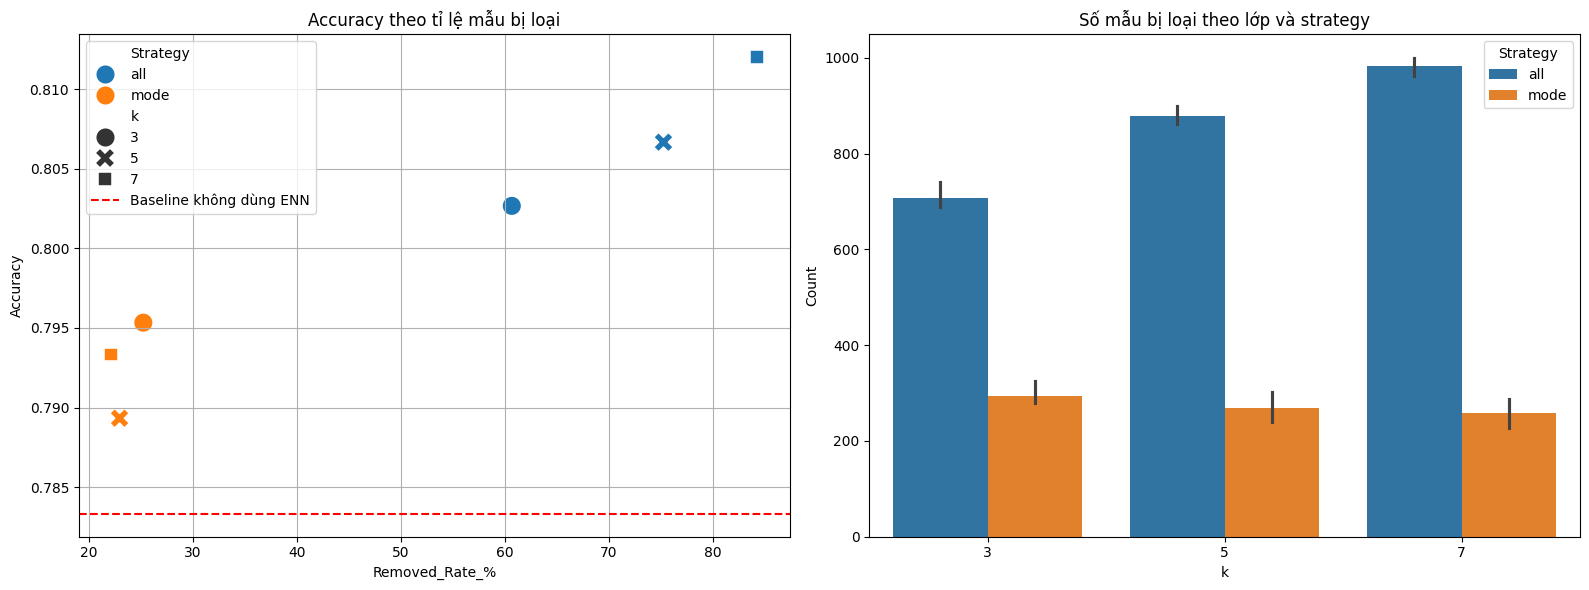

In [ ]:
# Vẽ biểu đồ so sánh
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df_detailed, x='Removed_Rate_%', y='Accuracy', hue='Strategy', style='k', s=200, ax=ax1)
ax1.axhline(res_original['Accuracy'], color='red', linestyle='--', label='Baseline không dùng ENN')
ax1.set_title('Accuracy theo tỉ lệ mẫu bị loại')
ax1.grid(True)
ax1.legend()

rem_cols = [c for c in df_detailed.columns if 'Rem_Class_' in c]
df_rem = df_detailed.melt(id_vars=['Strategy', 'k'], value_vars=rem_cols, var_name='Class', value_name='Count')
sns.barplot(data=df_rem, x='k', y='Count', hue='Strategy', ax=ax2)
ax2.set_title('Số mẫu bị loại theo lớp và strategy')
plt.tight_layout()
plt.show()